In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 

In [17]:
df3 = pd.read_csv("exoplanet_data.csv", comment="#")
df3.head()

,pl_name,hostname,default_flag,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,soltype,pl_controv_flag,...,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2,rowupdate,pl_pubdate,releasedate
0,7 CMa c,7 CMa,0,1,2,Radial Velocity,2019,Multiple Observatories,Published Confirmed,0,...,-0.03,1.564,0.252,-0.252,3.67853,0.004135,-0.004135,2024-09-13,2024-07,2024-09-13
1,7 CMa c,7 CMa,1,1,2,Radial Velocity,2019,Multiple Observatories,Published Confirmed,0,...,-0.03,1.564,0.252,-0.252,3.67853,0.004135,-0.004135,2019-10-18,2019-11,2019-10-24
2,DMPP-1 b,DMPP-1,1,1,4,Radial Velocity,2019,La Silla Observatory,Published Confirmed,0,...,-0.03,6.690,0.024,-0.024,7.85032,0.000290,-0.000290,2026-03-05,2026-02,2026-03-05
3,DMPP-1 b,DMPP-1,0,1,4,Radial Velocity,2019,La Silla Observatory,Published Confirmed,0,...,-0.03,6.690,0.024,-0.024,7.85032,0.000290,-0.000290,2020-01-23,2019-12,2020-01-30
4,DMPP-1 c,DMPP-1,1,1,4,Radial Velocity,2019,La Silla Observatory,Published Confirmed,0,...,-0.03,6.690,0.024,-0.024,7.85032,0.000290,-0.000290,2026-03-05,2026-02,2026-03-05


In [20]:
df3.shape 
rows, cols = df3.shape
print(rows)
print(cols)
df3.columns

583
92


Index(['pl_name', 'hostname', 'default_flag', 'sy_snum', 'sy_pnum',
       'discoverymethod', 'disc_year', 'disc_facility', 'soltype',
       'pl_controv_flag', 'pl_refname', 'pl_orbper', 'pl_orbpererr1',
       'pl_orbpererr2', 'pl_orbperlim', 'pl_orbsmax', 'pl_orbsmaxerr1',
       'pl_orbsmaxerr2', 'pl_orbsmaxlim', 'pl_rade', 'pl_radeerr1',
       'pl_radeerr2', 'pl_radelim', 'pl_radj', 'pl_radjerr1', 'pl_radjerr2',
       'pl_radjlim', 'pl_bmasse', 'pl_bmasseerr1', 'pl_bmasseerr2',
       'pl_bmasselim', 'pl_bmassj', 'pl_bmassjerr1', 'pl_bmassjerr2',
       'pl_bmassjlim', 'pl_bmassprov', 'pl_orbeccen', 'pl_orbeccenerr1',
       'pl_orbeccenerr2', 'pl_orbeccenlim', 'pl_insol', 'pl_insolerr1',
       'pl_insolerr2', 'pl_insollim', 'pl_eqt', 'pl_eqterr1', 'pl_eqterr2',
       'pl_eqtlim', 'ttv_flag', 'st_refname', 'st_spectype', 'st_teff',
       'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_rad', 'st_raderr1',
       'st_raderr2', 'st_radlim', 'st_mass', 'st_masserr1', 'st_masserr2

In [ ]:
#I am unsure what the following columns represent:
#pl_orbeccan
#pl_insolerr1
#rastr
#sy_gaiamagerr2
#st_tefferr1

In [ ]:
#Planet Name -> pl_name -> Name of the exoplanet
#Host Name -> hostname -> Name of the star the planet orbits 
#Discovery Method -> discoverymethod -> How the planet was detected (transit, radial velocity, ect)
#Spectral Type -> st_spectype -> Classification of the star based on temperature/color
#Equilibrium Temperature -> pl_eqt -> Estimated temperature of the planet in Kelvin 
#Planet Mass -> pl_bmassj -> Mass of the planet in Jupiter masses 

In [25]:
df_small = df3[[
    'pl_name', 
    'hostname',
    'discoverymethod',
    'st_spectype',
    'pl_eqt',
    'pl_bmassj'
]] 

df_small

,pl_name,hostname,discoverymethod,st_spectype,pl_eqt,pl_bmassj
0,7 CMa c,7 CMa,Radial Velocity,NaN,NaN,0.912000
1,7 CMa c,7 CMa,Radial Velocity,NaN,NaN,0.870000
2,DMPP-1 b,DMPP-1,Radial Velocity,NaN,NaN,0.052859
3,DMPP-1 b,DMPP-1,Radial Velocity,F8 V,877.0,0.076362
4,DMPP-1 c,DMPP-1,Radial Velocity,NaN,NaN,0.034421
...,...,...,...,...,...,...
578,bet Pic c,bet Pic,Radial Velocity,NaN,1250.0,8.200000
579,bet Pic c,bet Pic,Radial Velocity,NaN,NaN,10.139000
580,bet Pic c,bet Pic,Radial Velocity,NaN,NaN,9.000000
581,eps Ind A b,eps Ind A,Radial Velocity,K5 V,275.0,6.310000


In [28]:
df_small = df_small.dropna()
df_small

,pl_name,hostname,discoverymethod,st_spectype,pl_eqt,pl_bmassj
3,DMPP-1 b,DMPP-1,Radial Velocity,F8 V,877.0,0.076362
5,DMPP-1 c,DMPP-1,Radial Velocity,F8 V,1239.0,0.030205
7,DMPP-1 d,DMPP-1,Radial Velocity,F8 V,1632.0,0.010540
8,DMPP-1 e,DMPP-1,Radial Velocity,F8 V,1314.0,0.012994
10,DMPP-2 b,DMPP-2,Radial Velocity,F5 V,1000.0,0.437000
...,...,...,...,...,...,...
561,WASP-185 b,WASP-185,Transit,G0 V,1160.0,0.980000
563,WASP-190 b,WASP-190,Transit,F6 IV-V,1500.0,1.000000
568,WASP-192 b,WASP-192,Transit,G0 V,1620.0,2.300000
572,XO-7 b,XO-7,Transit,G0 V,1743.0,0.709000


In [39]:
df_small.shape

(70, 6)

In [40]:
len(df_small)

70

In [41]:
len(df_small.columns)

6

In [42]:
df_small.head()

,pl_name,hostname,discoverymethod,st_spectype,pl_eqt,pl_bmassj
3,DMPP-1 b,DMPP-1,Radial Velocity,F8 V,877.0,0.076362
5,DMPP-1 c,DMPP-1,Radial Velocity,F8 V,1239.0,0.030205
7,DMPP-1 d,DMPP-1,Radial Velocity,F8 V,1632.0,0.010540
8,DMPP-1 e,DMPP-1,Radial Velocity,F8 V,1314.0,0.012994
10,DMPP-2 b,DMPP-2,Radial Velocity,F5 V,1000.0,0.437000


In [37]:
df_small.tail()

,pl_name,hostname,discoverymethod,st_spectype,pl_eqt,pl_bmassj
561,WASP-185 b,WASP-185,Transit,G0 V,1160.0,0.980
563,WASP-190 b,WASP-190,Transit,F6 IV-V,1500.0,1.000
568,WASP-192 b,WASP-192,Transit,G0 V,1620.0,2.300
572,XO-7 b,XO-7,Transit,G0 V,1743.0,0.709
581,eps Ind A b,eps Ind A,Radial Velocity,K5 V,275.0,6.310


In [38]:
df_small.columns

Index(['pl_name', 'hostname', 'discoverymethod', 'st_spectype', 'pl_eqt',
       'pl_bmassj'],
      dtype='object')

In [48]:
df_small["discoverymethod"].value_counts()

discoverymethod
Transit            55
Radial Velocity    13
Imaging             2
Name: count, dtype: int64

In [49]:
method_counts = df_small["discoverymethod"].value_counts()
print(method_counts)

print("Most common:")
print(method_counts.idxmax(), method_counts.max())

print("Least common:")
print(method_counts.idxmin(), method_counts.min())

discoverymethod
Transit            55
Radial Velocity    13
Imaging             2
Name: count, dtype: int64
Most common:
Transit 55
Least common:
Imaging 2


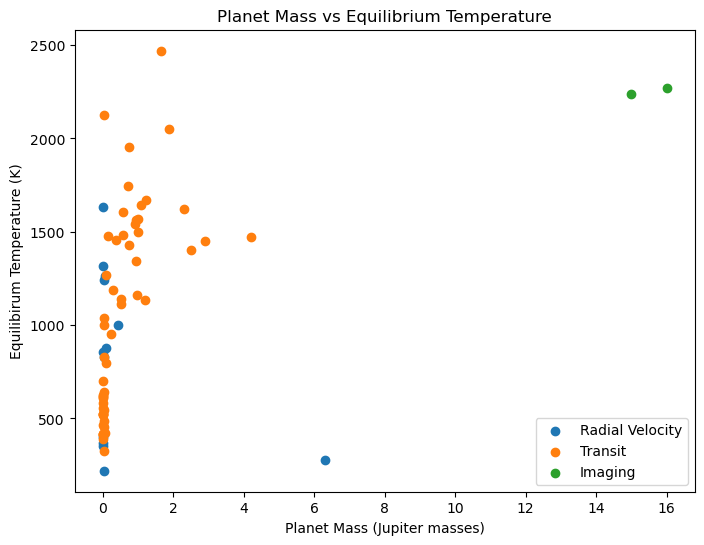

In [53]:
plt.figure(figsize=(8, 6))

for method in df_small["discoverymethod"].unique():
    subset = df_small[df_small["discoverymethod"] == method]
    plt.scatter(subset["pl_bmassj"], subset["pl_eqt"], label=method)

plt.title("Planet Mass vs Equilibrium Temperature") 
plt.xlabel("Planet Mass (Jupiter masses)")
plt.ylabel("Equilibirum Temperature (K)")
plt.legend()

plt.show()

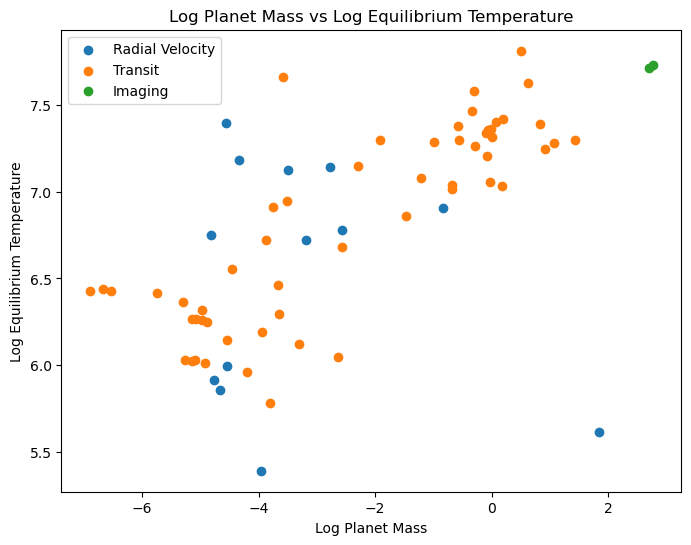

In [54]:
plt.figure(figsize=(8,6))

for method in df_small["discoverymethod"].unique():
    subset = df_small[df_small["discoverymethod"] == method]
    plt.scatter(np.log(subset["pl_bmassj"]), np.log(subset["pl_eqt"]), label=method)

plt.title("Log Planet Mass vs Log Equilibrium Temperature")
plt.xlabel("Log Planet Mass")
plt.ylabel("Log Equilibrium Temperature")
plt.legend()

plt.show()

In [55]:
df_small[df_small["discoverymethod"] == "Imaging"]

#Exoplanets found by the imaging method appear more likely to be massive than small

,pl_name,hostname,discoverymethod,st_spectype,pl_eqt,pl_bmassj
493,USco1556 b,USco1556 A,Imaging,M3.0 V,2240.0,15.0
494,USco1621 b,USco1621 A,Imaging,M2.5 V,2270.0,16.0


In [57]:
big_planets = df_small[df_small["pl_bmassj"] > 5]
big_planets 

coldest_planet = big_planets.loc[big_planets["pl_eqt"].idxmin()]
coldest_planet

pl_name                eps Ind A b
hostname                 eps Ind A
discoverymethod    Radial Velocity
st_spectype                   K5 V
pl_eqt                       275.0
pl_bmassj                     6.31
Name: 581, dtype: object

In [58]:
print(coldest_planet)

pl_name                eps Ind A b
hostname                 eps Ind A
discoverymethod    Radial Velocity
st_spectype                   K5 V
pl_eqt                       275.0
pl_bmassj                     6.31
Name: 581, dtype: object


In [59]:
coldest_index = big_planets["pl_eqt"].idxmin()

print("Name:", df_small.loc[coldest_index, "pl_name"])
print("Index:", coldest_index)
print("Equilibrium temperature:", df_small.loc[coldest_index, "pl_eqt"])
print("Mass:", df_small.loc[coldest_index, "pl_bmassj"])
print("Spectral type:", df_small.loc[coldest_index, "st_spectype"])

#The host star is not sun-like because its spectral type is not G-type (which is the spectral type of our Sun)

Name: eps Ind A b
Index: 581
Equilibrium temperature: 275.0
Mass: 6.31
Spectral type: K5 V


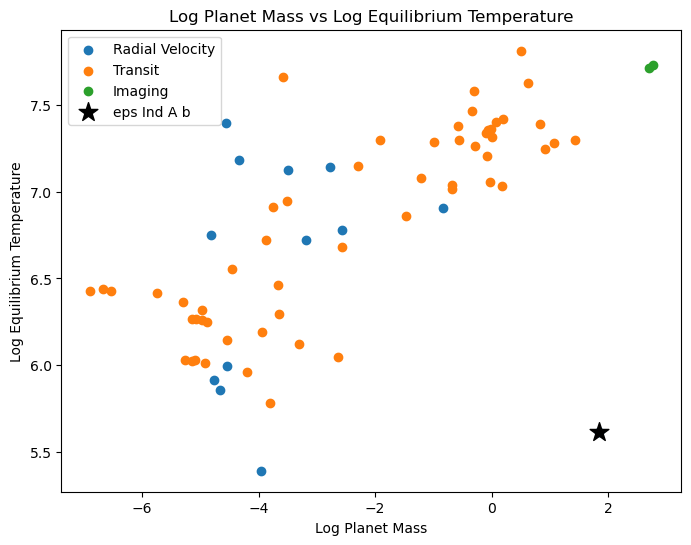

In [61]:
plt.figure(figsize=(8, 6))

for method in df_small["discoverymethod"].unique():
    subset = df_small[df_small["discoverymethod"] == method]
    plt.scatter(np.log(subset["pl_bmassj"]), np.log(subset["pl_eqt"]), label=method)

plt.scatter(
    np.log(coldest_planet["pl_bmassj"]),
    np.log(coldest_planet["pl_eqt"]),
    color="black",
    marker="*",
    s=200,
    label=coldest_planet["pl_name"]
)

plt.title("Log Planet Mass vs Log Equilibrium Temperature")
plt.xlabel("Log Planet Mass")
plt.ylabel("Log Equilibrium Temperature")
plt.legend()

plt.show()

In [1]:
#Article
#Paper title = A temperate super-Jupiter imaged with JWST in the mid-infrared
#Summary = The paper reports on the imaging of a giant exoplanet orbiting nearby 
#a sun like star using the James Webb Space Telescope. Scientists already had indreict
#evidence that a planet there existed, they were just uncertain about its properties/details. 
#They found out that the planet is a cold gas giant and appears to be bright in infrared wavelengths
#despite missing in others (suggesting an unexpected atmospheric composition). The properties they found
#match theoretical models of how old gas giant planets (like Jupiter) cool over time and gave us insight on 
#the history of Jupiter. 
#Does it match the exoplanet data? = Yes! Has same temperature and mass as the planet talked about in the article
#What is special about this planet? = it is one of the coldest imaged exoplanets since its discovery 
#Do mass and equilibrium temperature match? = Yes and yes